## Data understanding (non-visual)

### Imports

In [1]:

import sys
from pathlib import Path
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_theme(style="whitegrid")

project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))


from src.db import get_engine, fetch_table
from src.config import ID_COL, TARGET_COL, CATEGORICAL_COLS, NUMERIC_COLS, RATING_COLS

pd.set_option("display.max_columns",None)
pd.set_option("display.width", 200)

print("Project root:", project_root)


Project root: d:\OMEN-16\ML-Projects\airline-satisfaction-ml


## fetching the data

In [2]:
engine = get_engine()
df = fetch_table(engine)
print("shape:", df.shape)

shape: (129880, 24)


#### first 5 rows

In [3]:
df.head()

,id,gender,age,customer_type,type_of_travel,travel_class,flight_distance,departure_delay,arrival_delay,departure_arrival_time_convenience,ease_of_online_booking,checkin_service,online_boarding,gate_location,onboard_service,seat_comfort,leg_room_service,cleanliness,food_and_drink,inflight_service,inflight_wifi_service,inflight_entertainment,baggage_handling,satisfaction
0,1,Male,48,First-time,Business,Business,821,2,5.0,3,3,4,3,3,3,5,2,5,5,5,3,5,5,Neutral or Dissatisfied
1,2,Female,35,Returning,Business,Business,821,26,39.0,2,2,3,5,2,5,4,5,5,3,5,2,5,5,Satisfied
2,3,Male,41,Returning,Business,Business,853,0,0.0,4,4,4,5,4,3,5,3,5,5,3,4,3,3,Satisfied
3,4,Male,50,Returning,Business,Business,1905,0,0.0,2,2,3,4,2,5,5,5,4,4,5,2,5,5,Satisfied
4,5,Female,49,Returning,Business,Business,3470,0,1.0,3,3,3,5,3,3,4,4,5,4,3,3,3,3,Satisfied


#### Last 5 Rows

In [4]:
df.tail()

,id,gender,age,customer_type,type_of_travel,travel_class,flight_distance,departure_delay,arrival_delay,departure_arrival_time_convenience,ease_of_online_booking,checkin_service,online_boarding,gate_location,onboard_service,seat_comfort,leg_room_service,cleanliness,food_and_drink,inflight_service,inflight_wifi_service,inflight_entertainment,baggage_handling,satisfaction
129875,129876,Male,28,Returning,Personal,Economy Plus,447,2,3.0,4,4,4,4,2,5,1,4,4,4,5,4,4,4,Neutral or Dissatisfied
129876,129877,Male,41,Returning,Personal,Economy Plus,308,0,0.0,5,3,5,3,4,5,2,5,2,2,4,3,2,5,Neutral or Dissatisfied
129877,129878,Male,42,Returning,Personal,Economy Plus,337,6,14.0,5,2,4,2,1,3,3,4,3,3,4,2,3,5,Neutral or Dissatisfied
129878,129879,Male,50,Returning,Personal,Economy Plus,337,31,22.0,4,4,3,4,1,4,4,5,3,3,4,5,3,5,Satisfied
129879,129880,Female,20,Returning,Personal,Economy Plus,337,0,0.0,1,3,4,3,2,4,2,4,2,2,2,3,2,1,Neutral or Dissatisfied


#### Random rows

In [5]:
df.sample(10, random_state =42)

,id,gender,age,customer_type,type_of_travel,travel_class,flight_distance,departure_delay,arrival_delay,departure_arrival_time_convenience,ease_of_online_booking,checkin_service,online_boarding,gate_location,onboard_service,seat_comfort,leg_room_service,cleanliness,food_and_drink,inflight_service,inflight_wifi_service,inflight_entertainment,baggage_handling,satisfaction
103044,103037,Female,34,Returning,Business,Business,3402,66,67.0,1,3,3,2,1,1,3,1,4,4,1,1,1,1,Neutral or Dissatisfied
43282,43279,Female,32,First-time,Business,Economy,531,0,0.0,0,4,2,4,4,1,3,1,3,3,4,3,3,5,Neutral or Dissatisfied
65543,65541,Male,59,Returning,Business,Business,175,0,0.0,2,2,4,5,2,5,4,5,3,5,5,2,5,4,Satisfied
65083,65081,Female,69,Returning,Personal,Economy,224,0,11.0,4,0,3,5,4,2,5,0,5,3,2,3,2,5,Neutral or Dissatisfied
76496,76493,Female,60,Returning,Business,Business,516,0,0.0,4,4,3,5,4,4,5,4,3,3,4,4,4,4,Satisfied
78319,78319,Male,57,Returning,Business,Business,1547,0,0.0,4,4,5,5,4,4,4,4,4,2,4,4,4,4,Satisfied
43712,43709,Female,21,Returning,Personal,Economy,489,0,11.0,1,2,2,2,3,3,2,3,1,1,3,2,1,3,Neutral or Dissatisfied
8092,8093,Female,60,Returning,Business,Business,125,0,2.0,1,4,4,5,4,4,4,4,5,3,4,4,4,4,Satisfied
105253,105246,Female,33,Returning,Personal,Economy Plus,377,32,17.0,5,1,4,1,3,5,3,4,3,3,4,1,3,5,Neutral or Dissatisfied
71027,71024,Female,43,Returning,Business,Economy,978,15,0.0,4,4,1,4,4,4,4,4,2,4,4,4,4,4,Neutral or Dissatisfied


### Structure of the Data

In [6]:
print("Rows :", df.shape[0])
print("Columns :", df.shape[1])
print("Memory : {:.1f} MB".format(df.memory_usage(deep=True).sum()/ 1024**2))
print()
print(df.dtypes.value_counts())

Rows : 129880
Columns : 24
Memory : 29.6 MB

int64      18
str         5
float64     1
Name: count, dtype: int64


### checking if config list covers all columns

In [7]:
all_listed = [ID_COL,TARGET_COL] + CATEGORICAL_COLS + NUMERIC_COLS + RATING_COLS
print("Columns listed in the config.py:", len(all_listed))
print("In the data but not listed : ", set(df.columns) - set(all_listed))
print("Listed but not in the data : ", set(all_listed) - set(df.columns))


Columns listed in the config.py: 24
In the data but not listed :  set()
Listed but not in the data :  set()


## Numeric Columns

In [8]:
df[NUMERIC_COLS].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
age,129880.0,39.43,15.12,7.0,27.0,40.0,51.0,85.0
flight_distance,129880.0,1190.32,997.45,31.0,414.0,844.0,1744.0,4983.0
departure_delay,129880.0,14.71,38.07,0.0,0.0,0.0,12.0,1592.0
arrival_delay,129487.0,15.09,38.47,0.0,0.0,0.0,13.0,1584.0


#### Summary of Ratings columns

In [9]:
df[RATING_COLS].describe().T[["count","mean","min","max"]].round(2)

,count,mean,min,max
departure_arrival_time_convenience,129880.0,3.06,0.0,5.0
ease_of_online_booking,129880.0,2.76,0.0,5.0
checkin_service,129880.0,3.31,0.0,5.0
online_boarding,129880.0,3.25,0.0,5.0
gate_location,129880.0,2.98,0.0,5.0
onboard_service,129880.0,3.38,0.0,5.0
seat_comfort,129880.0,3.44,0.0,5.0
leg_room_service,129880.0,3.35,0.0,5.0
cleanliness,129880.0,3.29,0.0,5.0
food_and_drink,129880.0,3.20,0.0,5.0


## Categorical columns

In [10]:
df[CATEGORICAL_COLS + [TARGET_COL]].describe().T

,count,unique,top,freq
gender,129880,2,Female,65899
customer_type,129880,2,Returning,106100
type_of_travel,129880,2,Business,89693
travel_class,129880,3,Business,62160
satisfaction,129880,2,Neutral or Dissatisfied,73452


#### Full counts with Percentages

In [11]:
for col in CATEGORICAL_COLS + [TARGET_COL]:
    counts = df[col].value_counts()
    summary = pd.DataFrame({"count": counts, "percent": (counts / len(df) * 100).round(1)})
    print("---", col, "---")
    print(summary)
    print()

--- gender ---
        count  percent
gender                
Female  65899     50.7
Male    63981     49.3

--- customer_type ---
                count  percent
customer_type                 
Returning      106100     81.7
First-time      23780     18.3

--- type_of_travel ---
                count  percent
type_of_travel                
Business        89693     69.1
Personal        40187     30.9

--- travel_class ---
              count  percent
travel_class                
Business      62160     47.9
Economy       58309     44.9
Economy Plus   9411      7.2

--- satisfaction ---
                         count  percent
satisfaction                           
Neutral or Dissatisfied  73452     56.6
Satisfied                56428     43.4



for 

## RATING COLUMNS

In [12]:
# Score counts

rating_counts = df[RATING_COLS].apply(lambda s: s.value_counts()).fillna(0).astype(int)
rating_counts = rating_counts.sort_index().T
rating_counts.columns = ["score_" + str(c) for c in rating_counts.columns]
rating_counts

,score_0,score_1,score_2,score_3,score_4,score_5
departure_arrival_time_convenience,6681,19409,21534,22378,31880,27998
ease_of_online_booking,5682,21886,30051,30393,24444,17424
checkin_service,1,16108,16102,35453,36333,25883
online_boarding,3080,13261,21934,27117,38468,26020
gate_location,1,21991,24296,35717,30466,17409
onboard_service,5,14787,18351,28542,38703,29492
seat_comfort,1,15108,18529,23328,39756,33158
leg_room_service,598,12895,24540,25056,35886,30905
cleanliness,14,16729,20113,30639,33969,28416
food_and_drink,132,16051,27383,27794,30563,27957


In [13]:
# just the zeros,ranked

zeros = (df[RATING_COLS] == 0).sum()
zero_report = pd.DataFrame({"zero_count": zeros, "percent": (zeros / len(df) * 100).round(2)})
zero_report.sort_values("zero_count", ascending=False)


,zero_count,percent
departure_arrival_time_convenience,6681,5.14
ease_of_online_booking,5682,4.37
inflight_wifi_service,3916,3.02
online_boarding,3080,2.37
leg_room_service,598,0.46
food_and_drink,132,0.10
inflight_entertainment,18,0.01
cleanliness,14,0.01
onboard_service,5,0.00
inflight_service,5,0.00


#

## Missing values

In [14]:
## question :  which columns have missing values or blanks?

missing = df.isnull().sum()
missing_report = pd.DataFrame({"missing": missing, "percent": (missing /len(df) * 100).round(2)})
print("Columns with any missing values:")
print(missing_report[missing_report["missing"] > 10])
print()
print("Total missing cells in the whole table:", int(missing.sum()))

Columns with any missing values:
               missing  percent
arrival_delay      393      0.3

Total missing cells in the whole table: 393


#### are blank rows are different from the rest?

In [15]:


missing_rows = df[df["arrival_delay"].isnull()]
other_rows = df[df["arrival_delay"].notnull()]

print("Rows with missing arrival_delay:", len(missing_rows))
print("Average departure delay, those rows :", round(missing_rows['departure_delay'].mean(),1), "min")
print("Average departure delay, other rows :", round(other_rows["departure_delay"].mean(), 1), "min")
print("Share satisfied, those rows :", round((missing_rows[TARGET_COL] == "Satisfied").mean() * 100, 1), "%")
print("Share satisfied, other rows :", round((other_rows[TARGET_COL] == "Satisfied").mean() * 100, 1), "%")

Rows with missing arrival_delay: 393
Average departure delay, those rows : 37.9 min
Average departure delay, other rows : 14.6 min
Share satisfied, those rows : 42.2 %
Share satisfied, other rows : 43.4 %


## Duplicates

In [16]:
print("fully duplicated rows :", df.duplicated().sum())
print("Is id unique :", df[ID_COL].is_unique)
print("Duplicates if we ignore id :0", df.drop(columns=ID_COL).duplicated().sum())

fully duplicated rows : 0
Is id unique : True
Duplicates if we ignore id :0 0


## Target balance

In [17]:
target_counts = df[TARGET_COL].value_counts()
print(target_counts)
print()
print((target_counts / len(df) * 100).round(1))
print()
print("Imbalance ratio (bigger : smaller) = {:.2f} : 1".format(target_counts.max() / target_counts.min()))
print("Accuracy of always gussing the bigger class = {:.1%}".format(target_counts.max() / len(df)))

satisfaction
Neutral or Dissatisfied    73452
Satisfied                  56428
Name: count, dtype: int64

satisfaction
Neutral or Dissatisfied    56.6
Satisfied                  43.4
Name: count, dtype: float64

Imbalance ratio (bigger : smaller) = 1.30 : 1
Accuracy of always gussing the bigger class = 56.6%


## Checking Skewness and Outliers

In [18]:
# skewness

df[NUMERIC_COLS].skew().round(2)

age               -0.00
flight_distance    1.11
departure_delay    6.82
arrival_delay      6.67
dtype: float64

In [19]:
# IQR Rule

def iqr_summary(series):
    s = series.dropna()
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5*iqr, q3 + 1.5*iqr
    n_out = int(((s < lower) | (s > upper)).sum())
    return pd.Series({
        "min": s.min(), "Q1": q1, "median": s.median(), "Q3": q3, "max": s.max(),
        "lower_fence": lower, "upper_fence":upper,
        "outliers":n_out, "percent": round(n_out / len(s) * 100, 1),
    })

pd.DataFrame({col: iqr_summary(df[col]) for col in NUMERIC_COLS}).T

,min,Q1,median,Q3,max,lower_fence,upper_fence,outliers,percent
age,7.0,27.0,40.0,51.0,85.0,-9.0,87.0,0.0,0.0
flight_distance,31.0,414.0,844.0,1744.0,4983.0,-1581.0,3739.0,2855.0,2.2
departure_delay,0.0,0.0,0.0,12.0,1592.0,-18.0,30.0,18098.0,13.9
arrival_delay,0.0,0.0,0.0,13.0,1584.0,-19.5,32.5,17492.0,13.5


In [20]:
# percentile to see the long tail

percentiles = [0.5,0.9,0.95,0.99,1.0]
df[["flight_distance","departure_delay", "arrival_delay"]].quantile(percentiles)

,flight_distance,departure_delay,arrival_delay
0.50,844.0,0.0,0.0
0.90,2751.0,44.0,44.0
0.95,3380.0,77.0,78.0
0.99,3884.0,180.0,182.0
1.00,4983.0,1592.0,1584.0


## Impossible values and text Consistency


In [21]:
impossible = {
    "age below 5 or above 100": int(((df["age"]<5) | (df["age"]>100)).sum()),
    "flight_distance of 0 or less": int((df["flight_distance"]<=0).sum()),
    "negative departure_delay": int((df["departure_delay"]<0).sum()),
    "negative arrival_delay": int((df["arrival_delay"]<0).sum()),
    "rating outside 0 to 5": int((~df[RATING_COLS].isin(range(0,6))).sum().sum()),
}

for check, count in impossible.items():
    print(f"{check:<30}:{count}")

age below 5 or above 100      :0
flight_distance of 0 or less  :0
negative departure_delay      :0
negative arrival_delay        :0
rating outside 0 to 5         :0


## Early relationship with target

In [22]:
target_flag = (df[TARGET_COL] == "Satisfied").astype(int)

for col in CATEGORICAL_COLS:
    table = target_flag.groupby(df[col]).agg(["mean","count"])
    table["mean"] = (table["mean"] * 100).round(1)
    table.columns = ["percent_satisfied","passengers"]
    print("---",col,"---")
    print(table)
    print()

--- gender ---
        percent_satisfied  passengers
gender                               
Female               42.9       65899
Male                 44.0       63981

--- customer_type ---
               percent_satisfied  passengers
customer_type                               
First-time                  24.0       23780
Returning                   47.8      106100

--- type_of_travel ---
                percent_satisfied  passengers
type_of_travel                               
Business                     58.4       89693
Personal                     10.1       40187

--- travel_class ---
              percent_satisfied  passengers
travel_class                               
Business                   69.4       62160
Economy                    18.8       58309
Economy Plus               24.6        9411



#### travel type and class together

In [23]:


combo = target_flag.groupby([df["type_of_travel"], df["travel_class"]]).mean().unstack() * 100
combo.round(1)

travel_class,Business,Economy,Economy Plus
type_of_travel,,,
Business,72.0,29.9,39.3
Personal,11.7,10.2,8.7


#### satisfaction by age band

In [24]:


age_band = pd.cut(df["age"], bins=[0,17,25,35,45,55,65,100])
table =  target_flag.groupby(age_band, observed=True).agg(["mean","count"])
table["mean"] = (table["mean"] * 100).round(1)
table.columns = ["percent_satisfied", "passengers"]
table

,percent_satisfied,passengers
age,,
"(0, 17]",16.7,9847
"(17, 25]",34.7,18326
"(25, 35]",37.6,23572
"(35, 45]",52.1,30617
"(45, 55]",57.8,26239
"(55, 65]",46.3,16234
"(65, 100]",18.5,5045


#### correlation of every numeric column with target column

In [25]:
corr_with_target = df[RATING_COLS + NUMERIC_COLS].corrwith(target_flag).sort_values(ascending=False)
corr_with_target.round(3)

online_boarding                       0.502
inflight_entertainment                0.398
seat_comfort                          0.349
onboard_service                       0.322
leg_room_service                      0.312
cleanliness                           0.307
flight_distance                       0.298
inflight_wifi_service                 0.283
baggage_handling                      0.249
inflight_service                      0.245
checkin_service                       0.237
food_and_drink                        0.211
ease_of_online_booking                0.169
age                                   0.134
gate_location                        -0.003
departure_delay                      -0.051
departure_arrival_time_convenience   -0.054
arrival_delay                        -0.058
dtype: float64

#### delay columns against each other

In [26]:


print("Correlation, departure_delay vs arrival_delay:", round(df["departure_delay"].corr(df["arrival_delay"]),3))

Correlation, departure_delay vs arrival_delay: 0.965


## finding Suspicious patterns

In [27]:
# satisfaction by wifi score

wifi = target_flag.groupby(df["inflight_wifi_service"]).agg(["mean","count"])
wifi["mean"] = (wifi["mean"] * 100).round(1)
wifi.columns  = ["percent_satisfied", "passengers"]
wifi

,percent_satisfied,passengers
inflight_wifi_service,,
0,99.7,3916
1,32.8,22328
2,24.7,32320
3,25.2,32185
4,60.1,24775
5,99.0,14356


There is the strangest pattern in the data.

Scores 1, 2 and 3 give 25 to 33% satisfied. Fine.
Score 4 jumps to 60%.
Score 5: 99.0% satisfied.
Score 0 (didn't use wifi): 99.7% satisfied.

#### satisfaction when each rating is 0

In [28]:

rows = []
for col in RATING_COLS:
    is_zero = df[col] == 0
    if is_zero.sum() > 0:
        rows.append({
            "columns": col,
            "zero_count": int(is_zero.sum()),
            "percent_satisfied_when_zero": round(target_flag[is_zero].mean() * 100, 1),
        })

pd.DataFrame(rows).sort_values("zero_count", ascending=False).reset_index(drop=True)

,columns,zero_count,percent_satisfied_when_zero
0,departure_arrival_time_convenience,6681,48.1
1,ease_of_online_booking,5682,66.6
2,inflight_wifi_service,3916,99.7
3,online_boarding,3080,56.5
4,leg_room_service,598,34.4
5,food_and_drink,132,41.7
6,inflight_entertainment,18,0.0
7,cleanliness,14,0.0
8,onboard_service,5,0.0
9,inflight_service,5,0.0


#### how many zeros does a passenger have?

In [29]:

zeros_per_row = (df[RATING_COLS] == 0).sum(axis=1)
table = target_flag.groupby(zeros_per_row).agg(["mean","count"])
table.columns = ["percent_statisfied", "passengers"]
table.index.name = "zero_rating_in_row"
table

,percent_statisfied,passengers
zero_rating_in_row,,
0,0.426790,119567
1,0.341029,4548
2,0.376020,2452
3,0.852918,2570
4,0.986541,743


## The Data Quality Log

In [30]:
log = pd.DataFrame([
    ["id has no information", "id", "Unique for every row (1 to 129880)", "Low", "Drop before modelling", "Step 5"],
    ["Missing arrival_delay", "arrival_delay", "393 rows (0.30%); these rows had a longer average departure delay (37.9 vs 14.6 min)", "Medium", "Impute with the median inside the pipeline", "Step 5 and 8"],
    ["Zero means not applicable", "13 of the 14 rating columns (all except baggage_handling)", "Six columns have over 100 zeros: time convenience 6681, online booking 5682, wifi 3916, online boarding 3080, leg room 598, food and drink 132", "High", "Decide how to treat zeros; add a not-rated count", "Step 5"],
    ["Wifi zero and five are almost all satisfied", "inflight_wifi_service", "Score 0: 99.7% satisfied (3916 rows). Score 5: 99.0% satisfied (14356 rows)", "High", "Train with and without wifi, report both", "Step 5 and 12"],
    ["Rows with many zero ratings are mostly satisfied", "rating columns", "3 zeros: 85.3% satisfied. 4 zeros: 98.7% satisfied. No zeros: 42.7%", "Medium", "Create a num_not_rated feature and test it", "Step 5"],
    ["Heavy skew in delays and distance", "departure_delay, arrival_delay, flight_distance", "Skew 6.82, 6.67 and 1.11", "Medium", "Log transform or scaling for linear models; trees are not affected", "Step 8"],
    ["Many outliers in delays and distance", "departure_delay, arrival_delay, flight_distance", "Delays reach 1592 and 1584 min. IQR rule flags 13.9% and 13.5% of delay values, and 2.2% of flight distances", "Low", "Keep them (real flights); check effect on linear models", "Step 8 and 9"],
    ["Delay columns nearly identical", "departure_delay, arrival_delay", "Correlation 0.965", "Medium", "Keep one, or build a delay difference feature", "Step 5"],
    ["Age effect is not a straight line", "age", "Satisfaction rises to the 46-55 band then falls", "Low", "Try age groups", "Step 5"],
    ["Gate location barely related to target", "gate_location", "Correlation about 0.00", "Low", "Candidate to drop; test", "Step 5"],
    ["Target mildly imbalanced", "satisfaction", "43.4% Satisfied vs 56.6% not; guessing the bigger class gives 56.6%", "Low", "Stratified split; report F1 and ROC-AUC", "Step 7 and 10"],
    ["Target is text", "satisfaction", "Two text labels", "Low", "Map to 1 and 0", "Step 5"],
    ["Clean checks passed", "all", "No duplicates, no impossible values, no stray spaces in text", "None", "Nothing to do", "-"],
], columns=["issue", "columns", "evidence", "severity", "planned_action", "fix_in"])

log.to_csv(project_root / "reports" / "data_quality_log.csv", index=False)
print("Saved", len(log), "rows to reports/data_quality_log.csv")
log

Saved 13 rows to reports/data_quality_log.csv


,issue,columns,evidence,severity,planned_action,fix_in
0,id has no information,id,Unique for every row (1 to 129880),Low,Drop before modelling,Step 5
1,Missing arrival_delay,arrival_delay,393 rows (0.30%); these rows had a longer aver...,Medium,Impute with the median inside the pipeline,Step 5 and 8
2,Zero means not applicable,13 of the 14 rating columns (all except baggag...,Six columns have over 100 zeros: time convenie...,High,Decide how to treat zeros; add a not-rated count,Step 5
3,Wifi zero and five are almost all satisfied,inflight_wifi_service,Score 0: 99.7% satisfied (3916 rows). Score 5:...,High,"Train with and without wifi, report both",Step 5 and 12
4,Rows with many zero ratings are mostly satisfied,rating columns,3 zeros: 85.3% satisfied. 4 zeros: 98.7% satis...,Medium,Create a num_not_rated feature and test it,Step 5
5,Heavy skew in delays and distance,"departure_delay, arrival_delay, flight_distance","Skew 6.82, 6.67 and 1.11",Medium,Log transform or scaling for linear models; tr...,Step 8
6,Many outliers in delays and distance,"departure_delay, arrival_delay, flight_distance",Delays reach 1592 and 1584 min. IQR rule flags...,Low,Keep them (real flights); check effect on line...,Step 8 and 9
7,Delay columns nearly identical,"departure_delay, arrival_delay",Correlation 0.965,Medium,"Keep one, or build a delay difference feature",Step 5
8,Age effect is not a straight line,age,Satisfaction rises to the 46-55 band then falls,Low,Try age groups,Step 5
9,Gate location barely related to target,gate_location,Correlation about 0.00,Low,Candidate to drop; test,Step 5


# EDA - Visuals Understanding

NameError: name 'fig_folder' is not defined

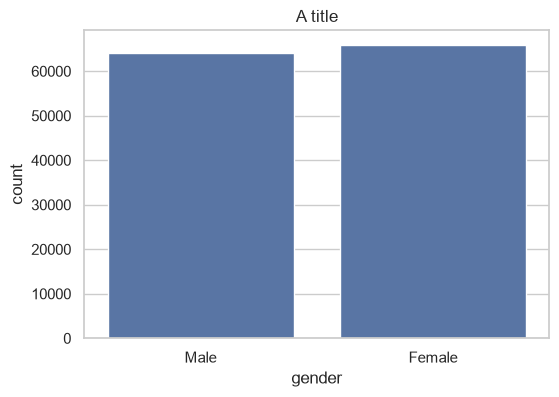

In [31]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="gender")
plt.title("A title")
plt.savefig(fig_folder + "name.png", dpi=120, bbox_inches="tight")
plt.show()

<Axes: xlabel='customer_type', ylabel='count'>

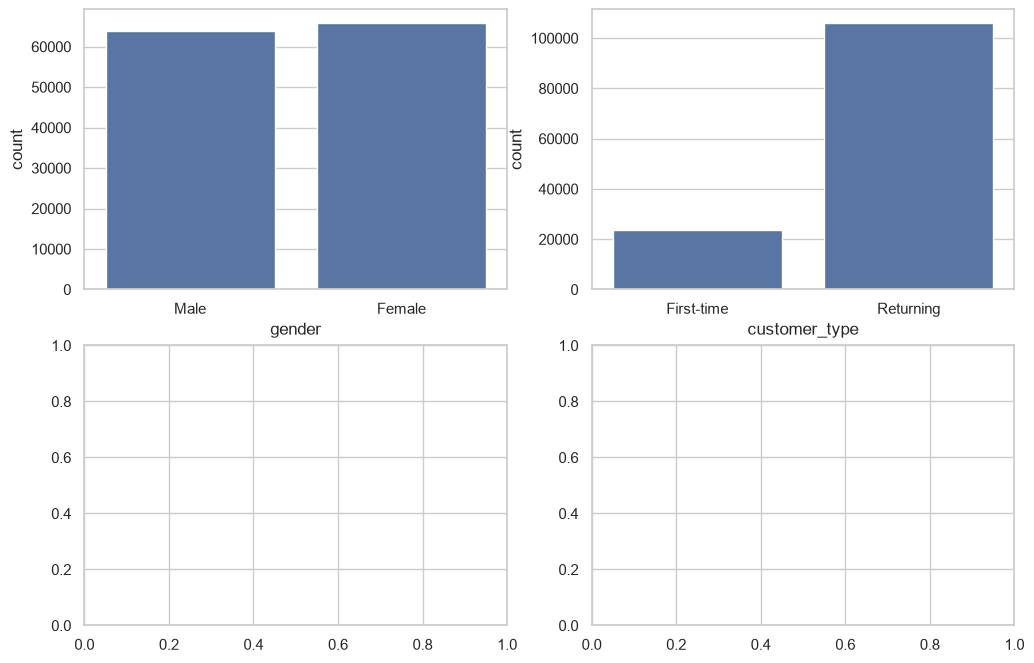

In [32]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

sns.countplot(data=df, x="gender", ax=axes[0, 0])
sns.countplot(data=df, x="customer_type", ax=axes[0, 1])

In [37]:
cat_cols = CATEGORICAL_COLS
num_cols = NUMERIC_COLS
rating_cols = RATING_COLS

fig_folder = "../reports/figures/"

eda = df.copy()

eda["satisfied"] = (eda["satisfaction"] == "Satisfied").astype(int)


eda["age_group"] = pd.cut(eda["age"],
                          bins = [0,17,25,35,45,55,65,100],
                          labels=["under 18","18-25","26-35","36-45","46-55","56-65","over 65"])


eda["distance_group"] = pd.cut(eda["flight_distance"],
                             bins = [0,500,1000,2000,3000,5000],
                             labels = ["under 500", "500-1000", "1000-2000", "2000-3000", "over 5000"])


eda["delay_group"] = pd.cut(eda["departure_delay"],
                            bins = [-1,0,15,60,180,2000],
                            labels = ["on time", "1-15 min", "16-60 min", "1-3 hours", "over 3 hours"])


eda["zero_ratings"] = (eda[rating_cols] == 0).sum(axis=1) 

print(eda.shape)
eda[["satisfied","age_group","distance_group","delay_group", "zero_ratings"]].head()

(129880, 29)


,satisfied,age_group,distance_group,delay_group,zero_ratings
0,0,46-55,500-1000,1-15 min,0
1,1,26-35,500-1000,16-60 min,0
2,1,36-45,500-1000,on time,0
3,1,46-55,1000-2000,on time,0
4,1,46-55,over 5000,on time,0


## Univariate Analysis

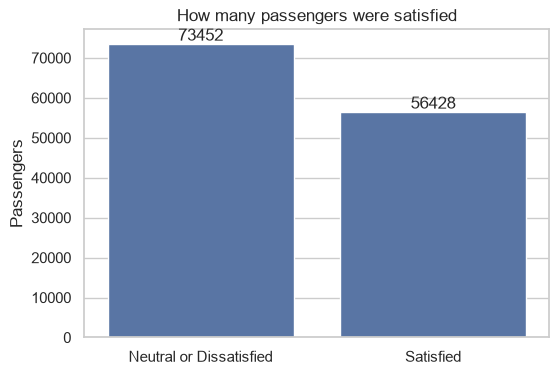

In [41]:
# count plot

plt.figure(figsize=(6, 4))
ax = sns.countplot(data=df, x="satisfaction")
ax.bar_label(ax.containers[0])
plt.title("How many passengers were satisfied")
plt.xlabel("")
plt.ylabel("Passengers")
plt.savefig(fig_folder + "01_target.png", dpi=120, bbox_inches="tight")
plt.show()


#### four categorical columns

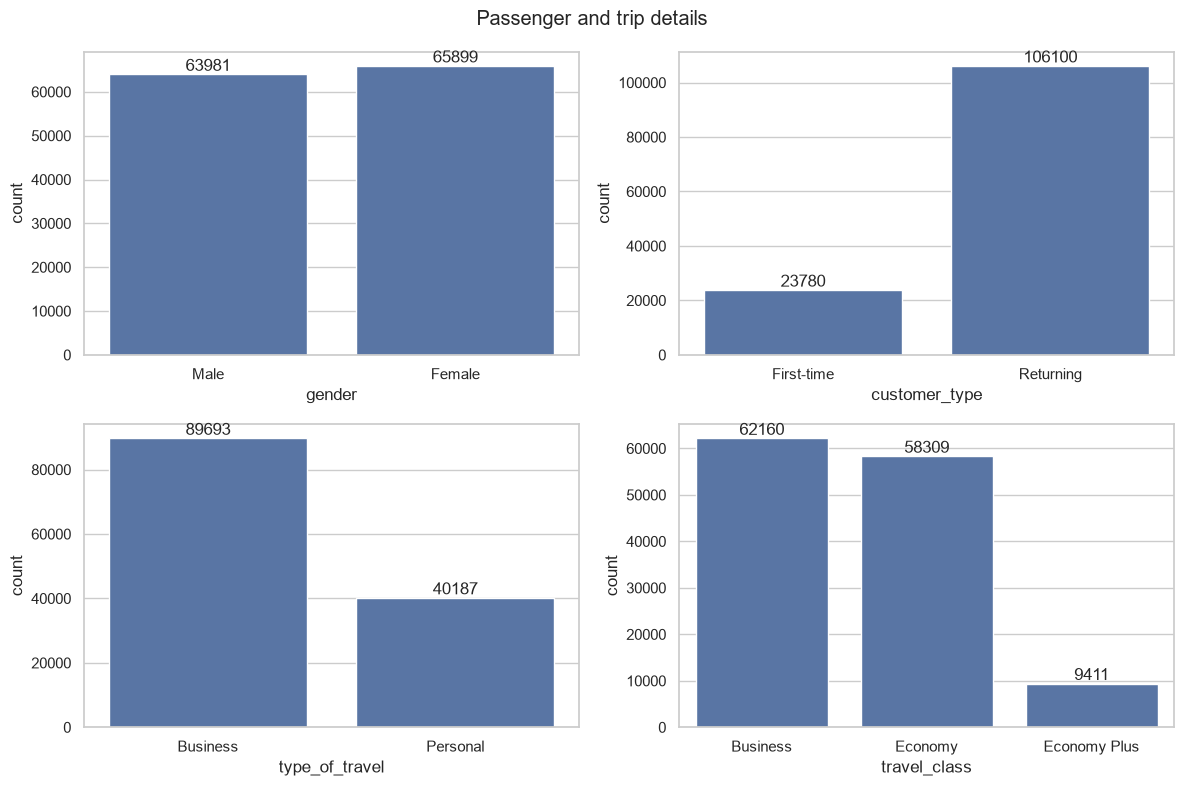

In [40]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

sns.countplot(data=df, x="gender", ax=axes[0, 0])
sns.countplot(data=df, x="customer_type", ax=axes[0, 1])
sns.countplot(data=df, x="type_of_travel", ax=axes[1, 0])
sns.countplot(data=df, x="travel_class", ax=axes[1, 1])

for ax in axes.flat:
    ax.bar_label(ax.containers[0])

fig.suptitle("Passenger and trip details")
plt.tight_layout()
plt.savefig(fig_folder + "02_categorical_columns.png", dpi=120, bbox_inches="tight")
plt.show()

#### Observation :
- gender: Female 65,899, Male 63,981. this is Almost equal.
- customer_type: Returning 106,100, First-time 23,780. Most of the passengers are returning.
- type_of_travel: Business 89,693, Personal 40,187.
- travel_class: Business 62,160, Economy 58,309, Economy Plus 9,411. Economy Plus  has very less count.

#### Histogram Age , Distance and Delays


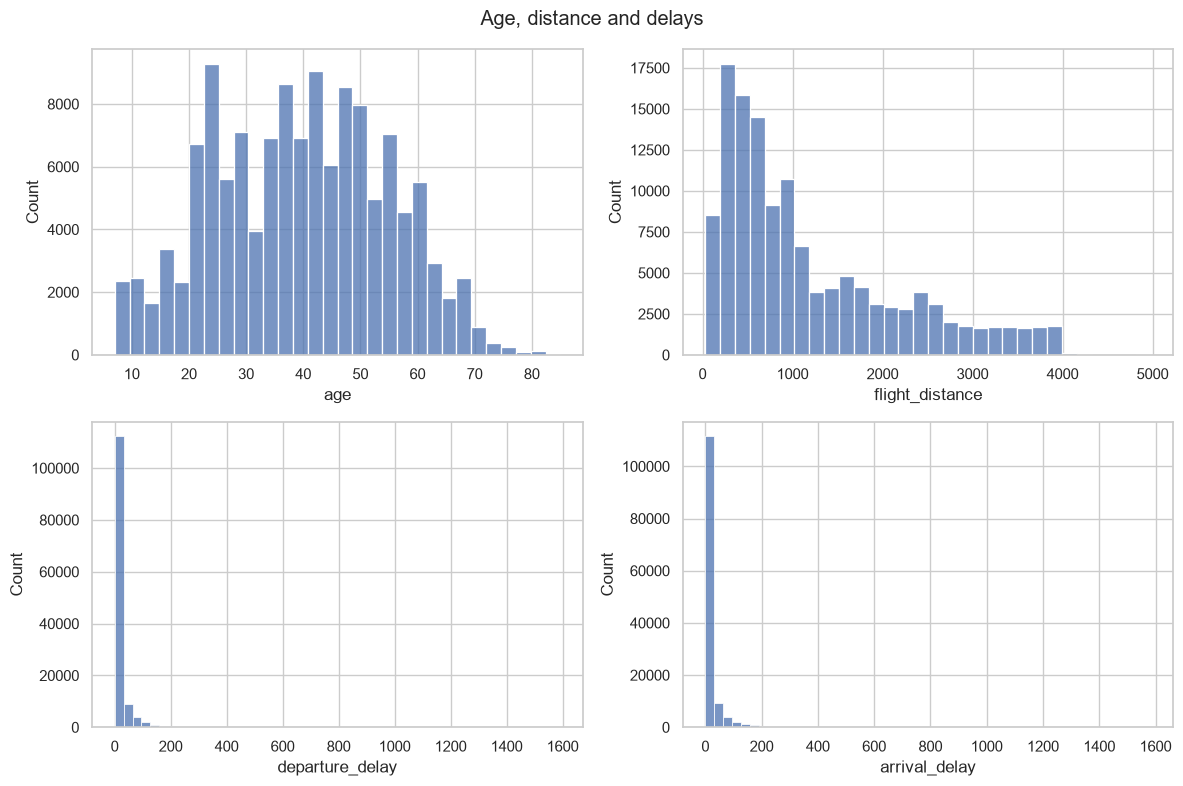

In [42]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

sns.histplot(data=df, x="age", bins=30, ax=axes[0, 0])
sns.histplot(data=df, x="flight_distance", bins=30, ax=axes[0, 1])
sns.histplot(data=df, x="departure_delay", bins=50, ax=axes[1, 0])
sns.histplot(data=df, x="arrival_delay", bins=50, ax=axes[1, 1])


fig.suptitle("Age, distance and delays")
plt.tight_layout()
plt.savefig(fig_folder + "03_histograms.png", dpi=120, bbox_inches="tight")
plt.show()

#### Observation

- age (top left): passengers from 7 to 85, with most between about 20 and 60. It's roughly balanced around 40, a bit lumpy.

- flight_distance (top right): a big pile of short flights (a few hundred miles), then a long tail out to about 4,000. Almost nothing beyond 4,000, even though a few flights reach 4,983. This is the right skew from Step 3 (skew 1.11).

- departure_delay and arrival_delay (bottom): one giant bar at 0 and almost nothing else visible. The tail stretches out to about 1,600 minutes but is too thin to see. This is the extreme skew (6.8 and 6.7) we measured.

####

#### delays,zoomed in

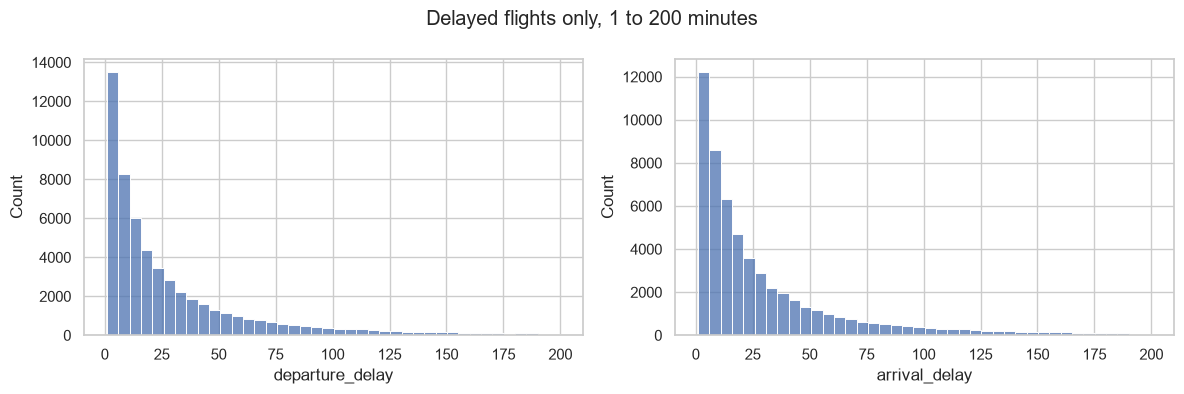

Flights delayed 1 to 200 minutes (departure): 55573
Flights delayed more than 200 minutes (departure): 951


In [44]:
# the delay charts above are squashed by the zeros, so look only at delayed flights

late_dep = df[(df["departure_delay"] > 0) & (df["departure_delay"] <= 200)]
late_arr = df[(df["arrival_delay"] > 0) & (df["arrival_delay"] <= 200)]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(data=late_dep, x="departure_delay", bins=40, ax=axes[0])
sns.histplot(data=late_arr, x="arrival_delay", bins=40, ax=axes[1])

fig.suptitle("Delayed flights only, 1 to 200 minutes")
plt.tight_layout()
plt.savefig(fig_folder + "04_delays_zoomed.png", dpi=120, bbox_inches="tight")
plt.show()

print("Flights delayed 1 to 200 minutes (departure):", len(late_dep))
print("Flights delayed more than 200 minutes (departure):", (df["departure_delay"] > 200).sum())


#### Box Plots

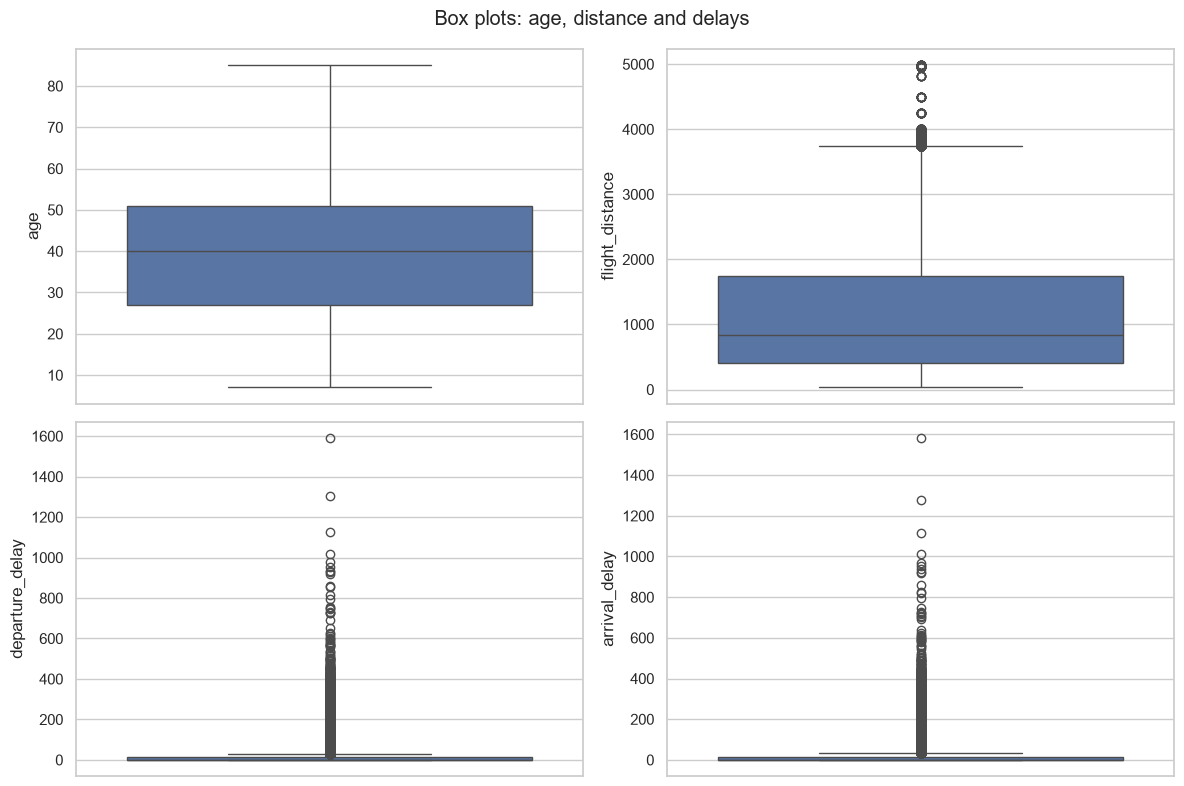

In [52]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

sns.boxplot(data=df, y="age", ax=axes[0, 0])
sns.boxplot(data=df, y="flight_distance", ax=axes[0, 1])
sns.boxplot(data=df, y="departure_delay", ax=axes[1, 0])
sns.boxplot(data=df, y="arrival_delay", ax=axes[1, 1])

fig.suptitle("Box plots: age, distance and delays")
plt.tight_layout()
plt.savefig(fig_folder + "05_boxplots.png", dpi=120, bbox_inches="tight")
plt.show()

Observation:

- age: a box from 25 to 52, median 40, whiskers covering the whole range. No dots, so no outliers.

- flight_distance: a box from 400 to 1,700 with a median of ~850, and a column of dots above about ~3,700. Those are the ~2,800 long flights (~2%) that the IQR rule flagged in above IQR Rule.

- departure_delay and arrival_delay: the box is squashed flat near 0 (it spans 0 to 10 or 15). Above it is a long column of dots reaching up to 1590
and 1580.

#### 14 Ratings,counted

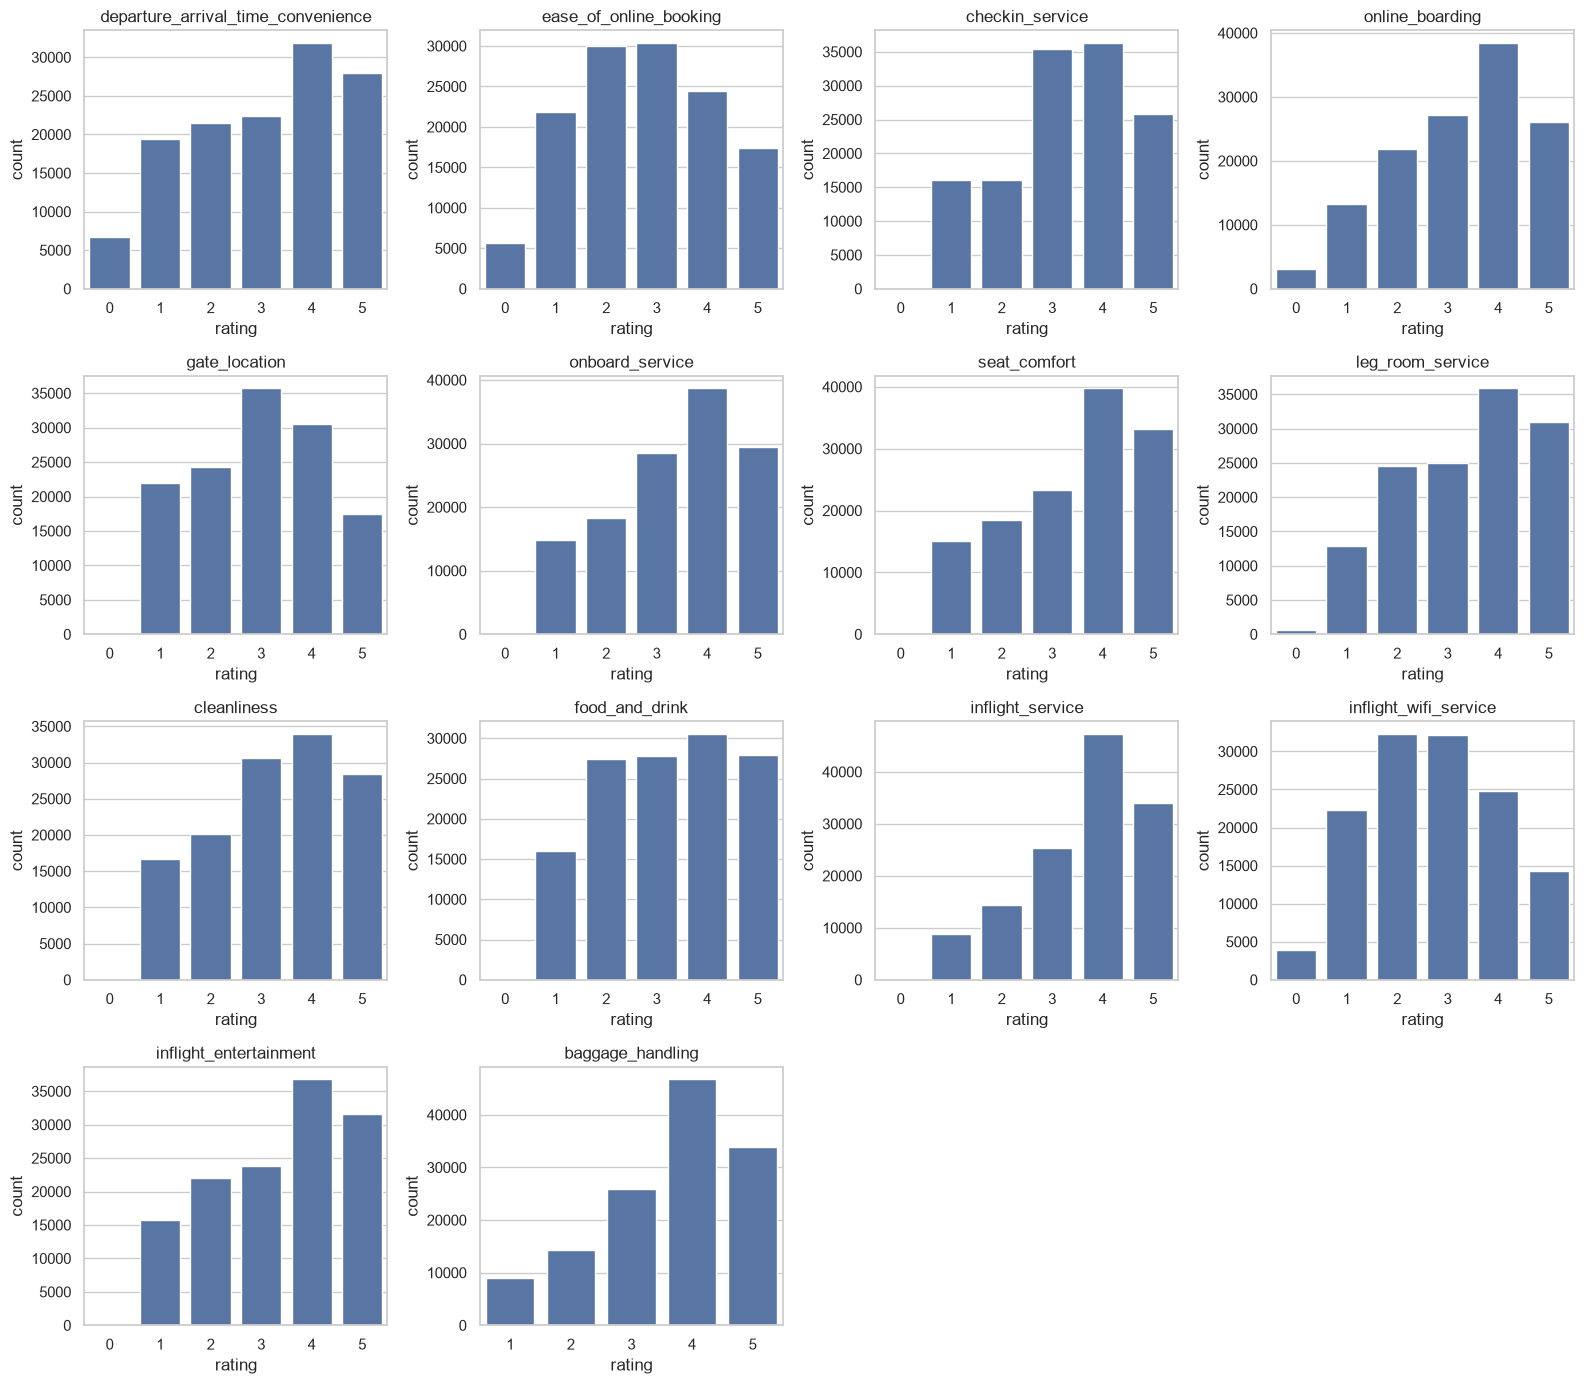

In [53]:
fig, axes = plt.subplots(4, 4, figsize=(16, 14))
axes = axes.flatten()

for i in range(14):
    sns.countplot(data=df, x=rating_cols[i], ax=axes[i])
    axes[i].set_title(rating_cols[i])
    axes[i].set_xlabel("rating")

# the grid has 16 boxes but only 14 ratings, so hide the last two
axes[14].axis("off")
axes[15].axis("off")

plt.tight_layout()
plt.savefig(fig_folder + "06_ratings_counts.png", dpi=120, bbox_inches="tight")
plt.show()

Observation:

- these are the 14 small charts about ratings

- Most ratings peak at 4. The 4 bar is the tallest in most of them.

- Wifi and online booking peak at 2 and 3 instead, which fits their low averages (2.73 and 2.76).

- Gate location peaks at 3.

- A 0 bar is clearly visible in four charts: departure and arrival time convenience, ease of online booking, wifi and online boarding. In the others, it's too small to see.

- Baggage handling has no 0 bar at all. Its scores start at 1.

## Bivariate Analysis

#### Categorical column Vs Satisfaction (Target Column)

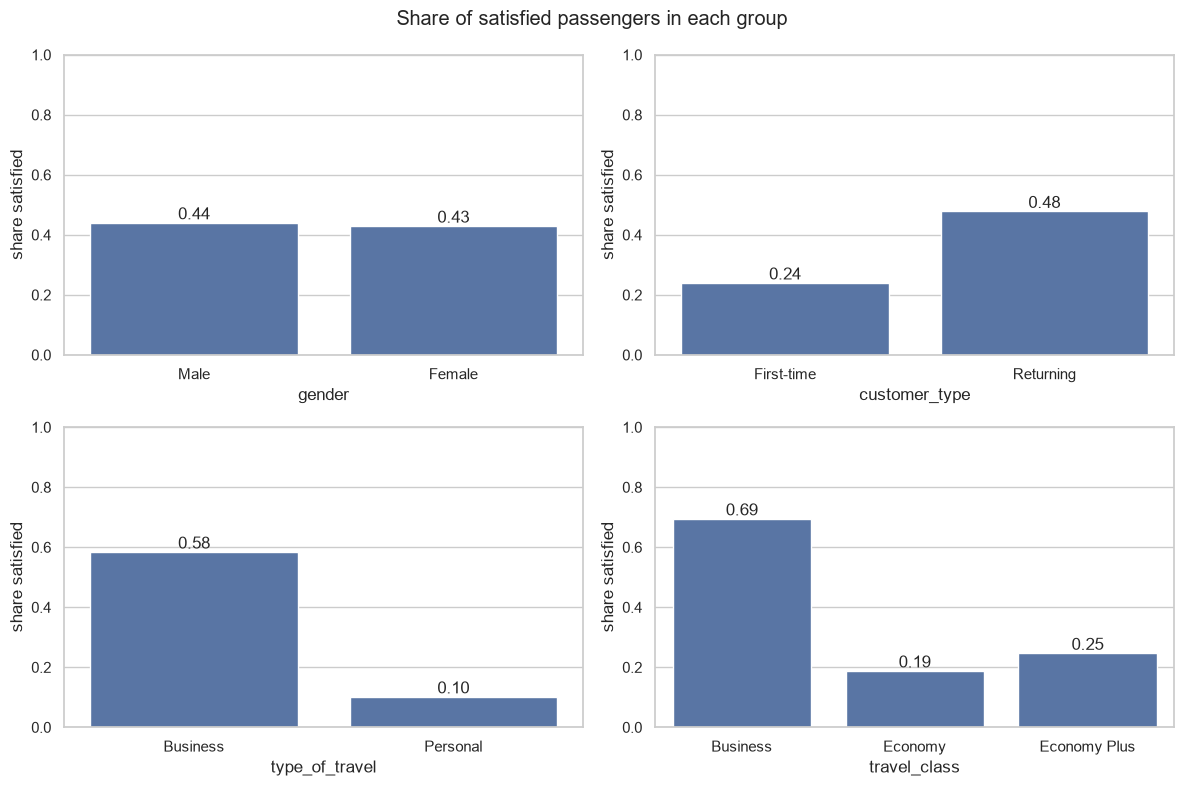

In [54]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

sns.barplot(data=eda, x="gender", y="satisfied", errorbar=None, ax=axes[0, 0])
sns.barplot(data=eda, x="customer_type", y="satisfied", errorbar=None, ax=axes[0, 1])
sns.barplot(data=eda, x="type_of_travel", y="satisfied", errorbar=None, ax=axes[1, 0])
sns.barplot(data=eda, x="travel_class", y="satisfied", errorbar=None, ax=axes[1, 1])

for ax in axes.flatten():
    ax.bar_label(ax.containers[0], fmt="%.2f")
    ax.set_ylim(0, 1)
    ax.set_ylabel("share satisfied")

fig.suptitle("Share of satisfied passengers in each group")
plt.tight_layout()
plt.savefig(fig_folder + "07_category_vs_satisfied.png", dpi=120, bbox_inches="tight")
plt.show()

Observation:
- Basically in chart gender makes no difference.
- And Customer type matters the most. here returning customers are twice as likely to be satisfied. 
- Also Type of travel is the biggest split (like 0.58 vs 0.10), 
- and travel class is close behind as Business is far above the other two.

#### 14 ratings Vs satisfaction

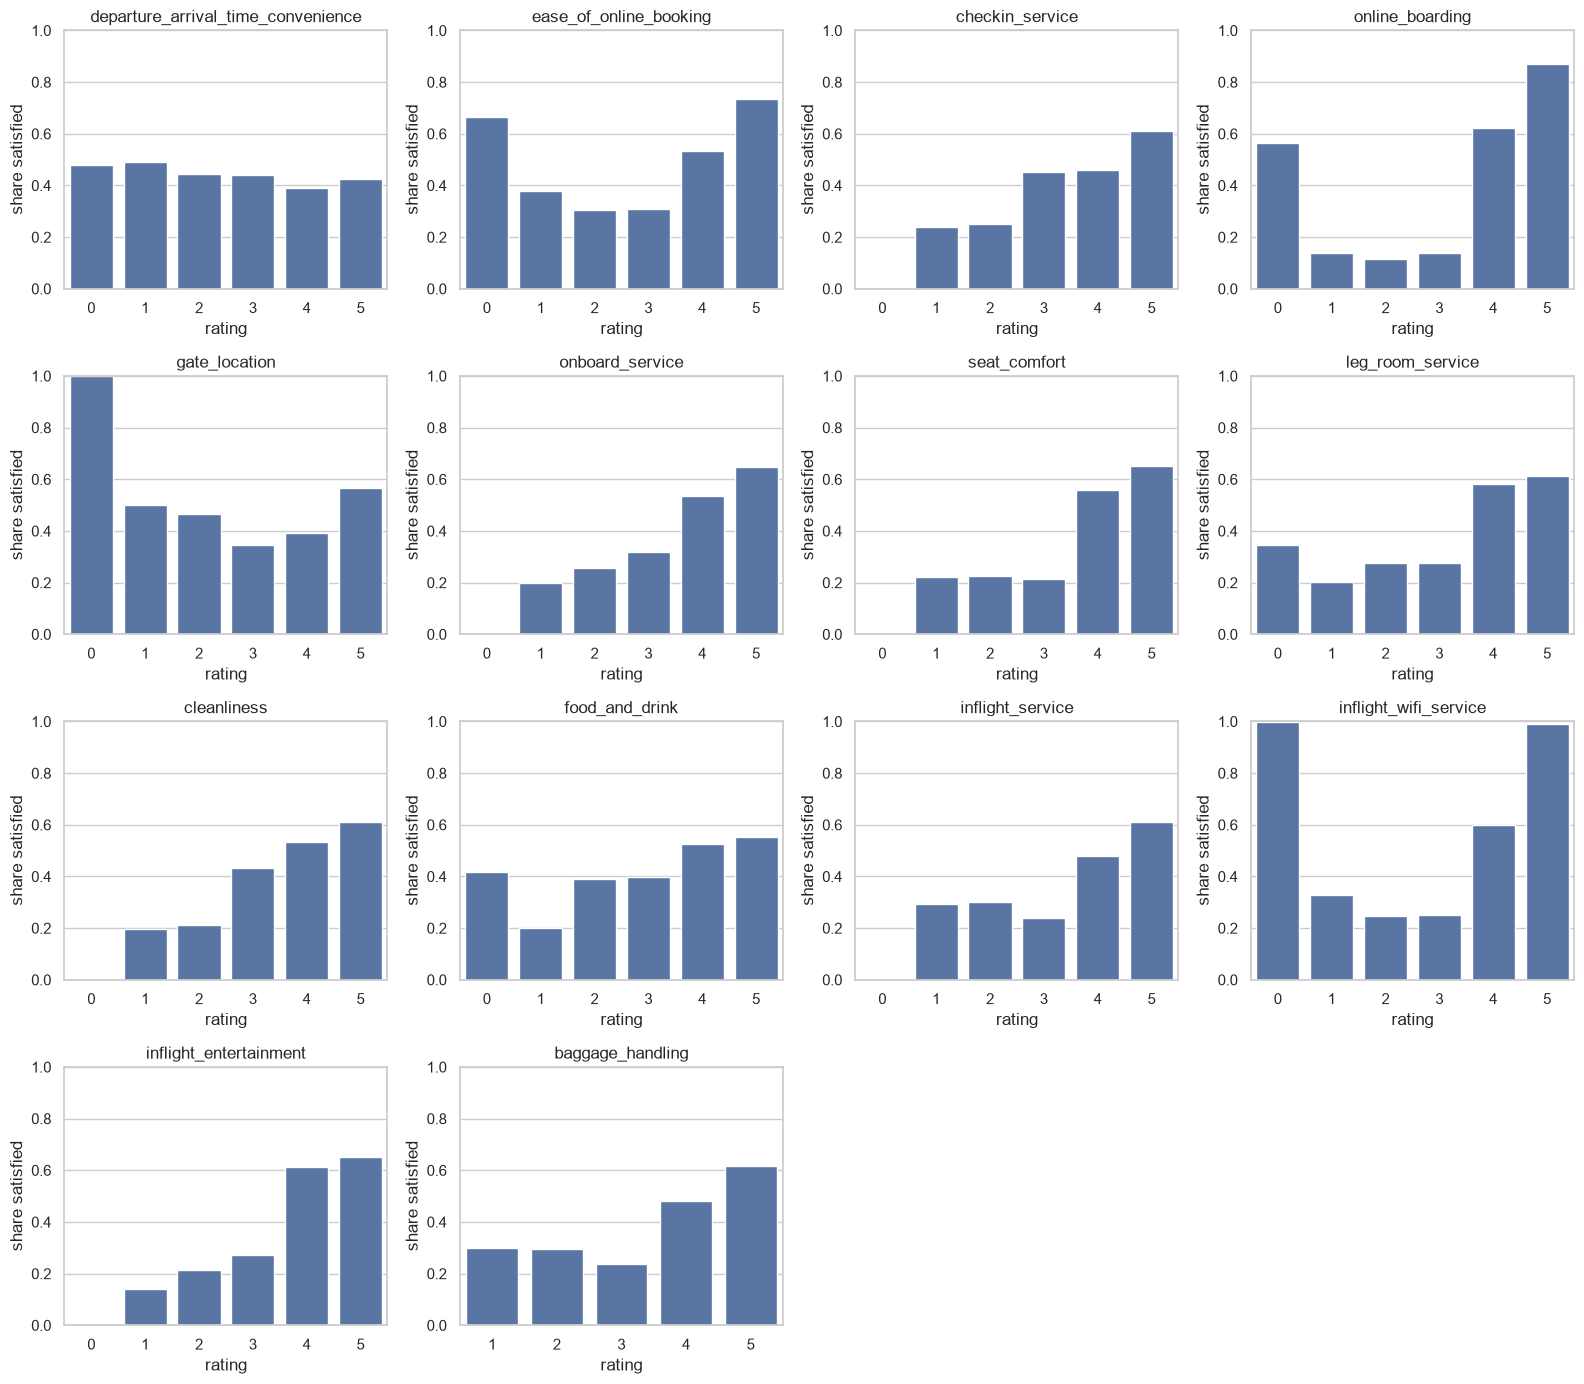

In [55]:
fig, axes = plt.subplots(4, 4, figsize=(16, 14))
axes = axes.flatten()

for i in range(14):
    sns.barplot(data=eda, x=rating_cols[i], y="satisfied", errorbar=None, ax=axes[i])
    axes[i].set_title(rating_cols[i])
    axes[i].set_xlabel("rating")
    axes[i].set_ylabel("share satisfied")
    axes[i].set_ylim(0, 1)

axes[14].axis("off")
axes[15].axis("off")

plt.tight_layout()
plt.savefig(fig_folder + "08_ratings_vs_satisfied.png", dpi=120, bbox_inches="tight")
plt.show()

observation :
- Seat comfort, leg room, in-flight service, baggage handling: a jump at score 4. Satisfaction is low and flat for scores 1 to 3, then climbs. Seat comfort is about 0.2 for scores 1 to 3, then 0.56 at 4 and 0.65 at 5. Leg room goes from about 0.2 to 0.3, then 0.58 at 4. In-flight service goes from about 0.3, then 0.48 at 4 and 0.61 at 5. Baggage handling is similar: about 0.3, then 0.48 and 0.62.

- On-board service, cleanliness, check-in, entertainment, food and drink: a steadier climb. On-board service runs 0.20, ~0.25, ~0.30, ~0.50, ~0.6 for scores 1 to 5. Cleanliness runs 0.20, ~0.25, ~0.40, ~0.50, ~0.60. Check-in runs ~0.25, ~0.25, ~0.45, ~0.45, ~0.60. Entertainment runs 0.14, 0.21, 0.27, 0.61, 0.65. Food and drink runs 0.20, ~0.40, ~0.40, ~0.50, ~0.55.

- Online boarding: about ~0.10 to ~0.15 for scores 1 to 3, then ~0.60 at 4 and ~0.90 at 5. The biggest jump of any rating.

- Wifi: a U shape, with tall bars at both 0 and 5.

- Ease of online booking: also U-shaped, but milder. The 0 bar is high (0.67).

- Departure and arrival time convenience: nearly flat, about 0.4 to 0.5 for every score. It almost has no signal.

- Gate location: no clear pattern. The 0 bar reaches 1.00, so ignore it.

#### Age Vs Satisfaction

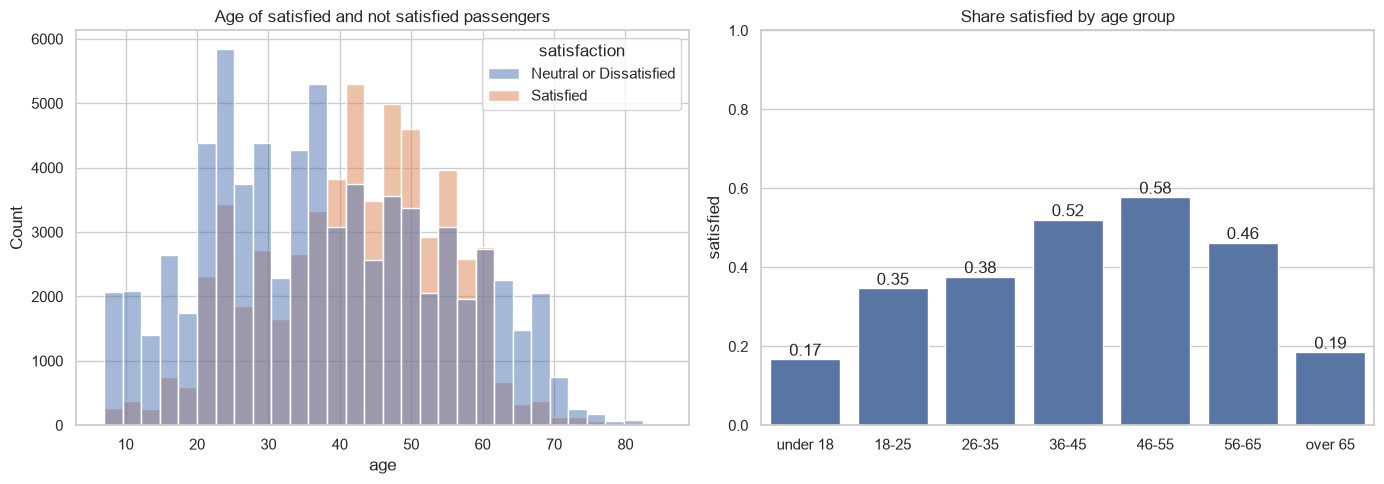

In [56]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(data=df, x="age", hue="satisfaction", bins=30, ax=axes[0])
axes[0].set_title("Age of satisfied and not satisfied passengers")

sns.barplot(data=eda, x="age_group", y="satisfied", errorbar=None, ax=axes[1])
axes[1].bar_label(axes[1].containers[0], fmt="%.2f")
axes[1].set_ylim(0, 1)
axes[1].set_title("Share satisfied by age group")
axes[1].set_xlabel("")

plt.tight_layout()
plt.savefig(fig_folder + "09_age.png", dpi=120, bbox_inches="tight")
plt.show()

observation:

- Left: a histogram of age, in two colours: not satisfied and satisfied. The not-satisfied group has more young and old passengers: 
The satisfied group is concentrated between 40 and 60. 

- Right: bars by age group. Share satisfied: under 18 17%, 18-25 35%, 26-35 38%, 36-45 52%, 46-55 58% (the peak), 56-65 46%, over 65 19%.

#### Flight Distance Vs Stisfaction

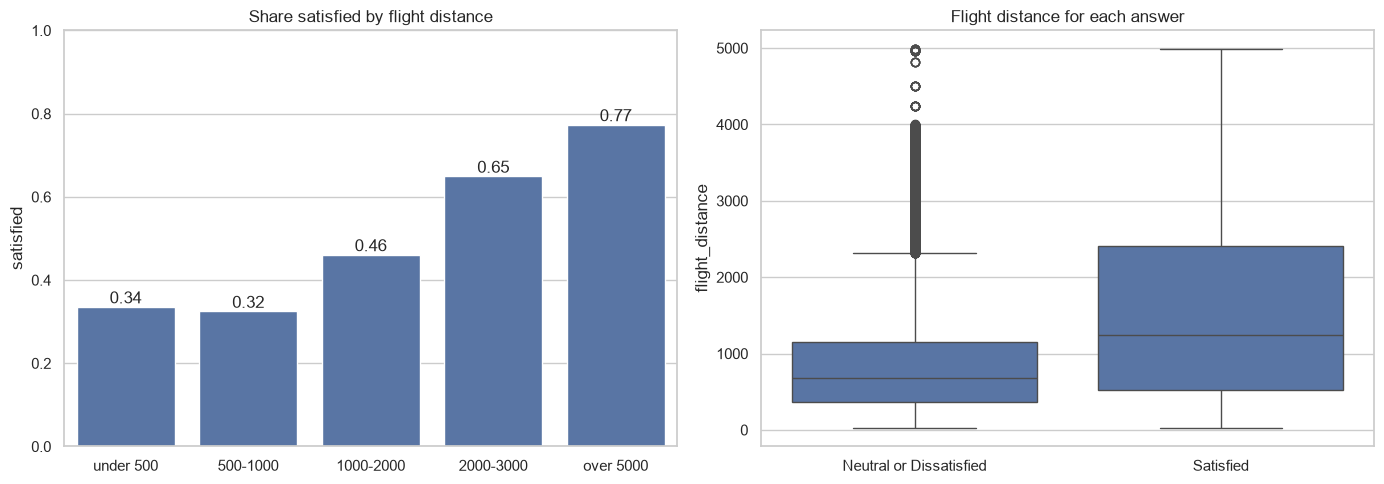

In [57]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=eda, x="distance_group", y="satisfied", errorbar=None, ax=axes[0])
axes[0].bar_label(axes[0].containers[0], fmt="%.2f")
axes[0].set_ylim(0, 1)
axes[0].set_title("Share satisfied by flight distance")
axes[0].set_xlabel("")

sns.boxplot(data=df, x="satisfaction", y="flight_distance", ax=axes[1])
axes[1].set_title("Flight distance for each answer")
axes[1].set_xlabel("")

plt.tight_layout()
plt.savefig(fig_folder + "10_distance.png", dpi=120, bbox_inches="tight")
plt.show()

observation:

- Left: share satisfied by distance band: under 500 about 34%, 500-1000 about 32%, 1000-2000 about 46%, 2000-3000 about 65%, over 3000 about 77%. It rises steadily with distance.

- Right: a box plot of flight distance for each answer. The satisfied box sits clearly higher. The median is about 1,200 miles for satisfied passengers and 600 for the others.

#### departure delay Vs Satisfaction

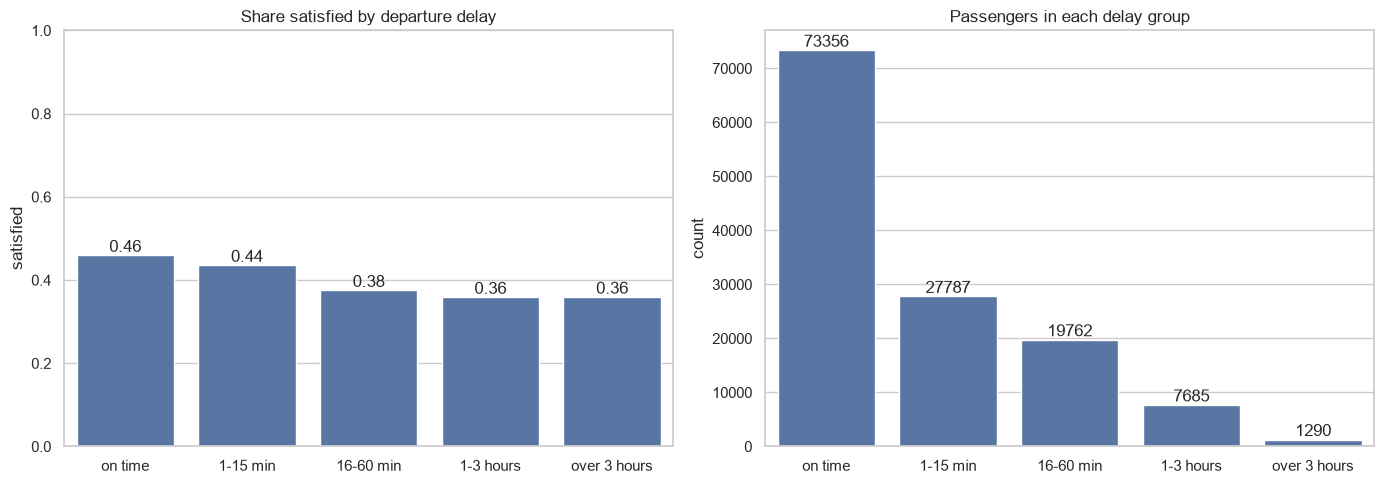

In [58]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=eda, x="delay_group", y="satisfied", errorbar=None, ax=axes[0])
axes[0].bar_label(axes[0].containers[0], fmt="%.2f")
axes[0].set_ylim(0, 1)
axes[0].set_title("Share satisfied by departure delay")
axes[0].set_xlabel("")

sns.countplot(data=eda, x="delay_group", ax=axes[1])
axes[1].bar_label(axes[1].containers[0])
axes[1].set_title("Passengers in each delay group")
axes[1].set_xlabel("")

plt.tight_layout()
plt.savefig(fig_folder + "11_delay.png", dpi=120, bbox_inches="tight")
plt.show()

observation :
- Left: share satisfied by delay band: on time about 46%, 1-15 minutes about 44%, 16-60 minutes about 38%, 1-3 hours about 36%, over 3 hours about 36%.

- Right: how many passengers sit in each band: on time 73,356; 1-15 min 27,787; 16-60 min 19,762; 1-3 hours 7,685; over 3 hours 1,290.

- here delays are lower satisfaction a little like about 10 points between on time and an hour late, and then the effect stops growing.

- A 5-hour delay is not worse than a 2-hour one. So delay is a weak signal, The right-hand chart reminds us the longest-delay group is smal

#### wifi, online boarding Vs Satisfaction

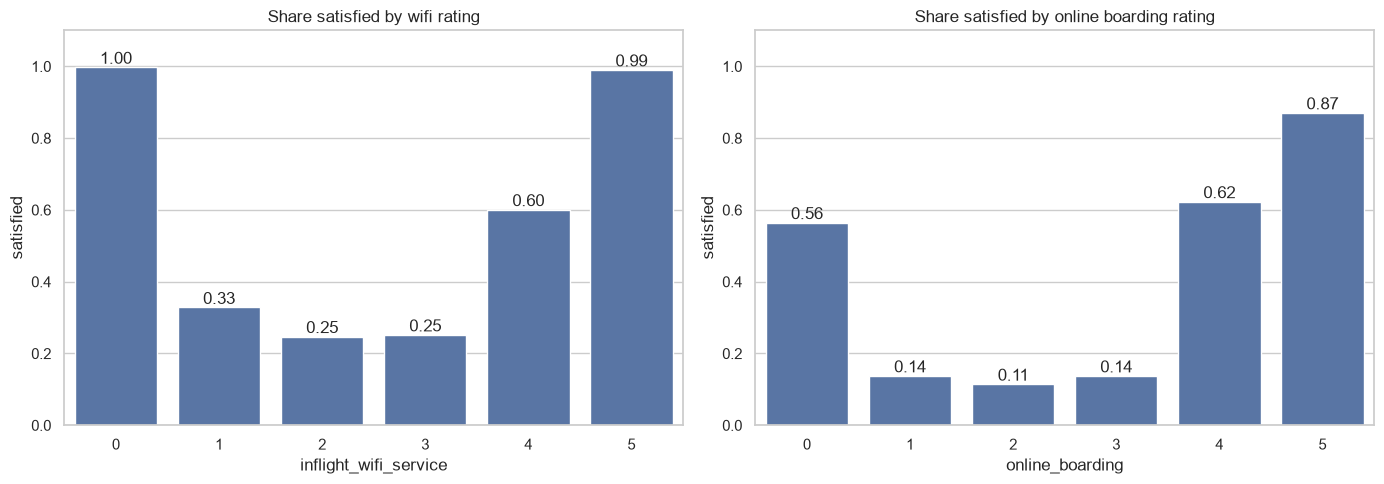

In [59]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=eda, x="inflight_wifi_service", y="satisfied", errorbar=None, ax=axes[0])
axes[0].bar_label(axes[0].containers[0], fmt="%.2f")
axes[0].set_ylim(0, 1.1)
axes[0].set_title("Share satisfied by wifi rating")

sns.barplot(data=eda, x="online_boarding", y="satisfied", errorbar=None, ax=axes[1])
axes[1].bar_label(axes[1].containers[0], fmt="%.2f")
axes[1].set_ylim(0, 1.1)
axes[1].set_title("Share satisfied by online boarding rating")

plt.tight_layout()
plt.savefig(fig_folder + "12_wifi_vs_boarding.png", dpi=120, bbox_inches="tight")
plt.show()

observation :

- both charts are low for scores 1 to 3 and jump at 4 and 5. That's a normal pattern for a rating: happy passengers give high scores. But wifi is odd at both ends.
- Score 0 (passengers who didn't use wifi) is almost 100% satisfied, which is not realistic, and score 5 reaches 99%.
-  Online boarding's 0 group is just near the average (0.5).

- The wifi pattern looks like a feature of how this dataset was made


#### how Many ratings are zero (zero ratings Vs satisfaction)

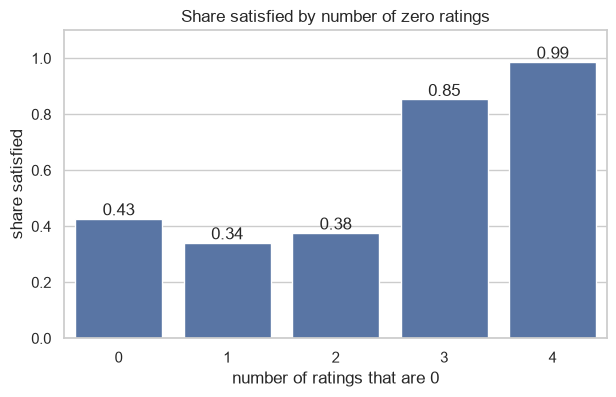

In [60]:
plt.figure(figsize=(7, 4))
ax = sns.barplot(data=eda, x="zero_ratings", y="satisfied", errorbar=None)
ax.bar_label(ax.containers[0], fmt="%.2f")
plt.ylim(0, 1.1)
plt.title("Share satisfied by number of zero ratings")
plt.xlabel("number of ratings that are 0")
plt.ylabel("share satisfied")
plt.savefig(fig_folder + "13_zero_ratings.png", dpi=120, bbox_inches="tight")
plt.show()

observation:

- passengers with three or four "not applicable" ratings are almost all satisfied, while having one or two zeros slightly lowers satisfaction.


#### Average Rating : Satisfied vs Not satisfied

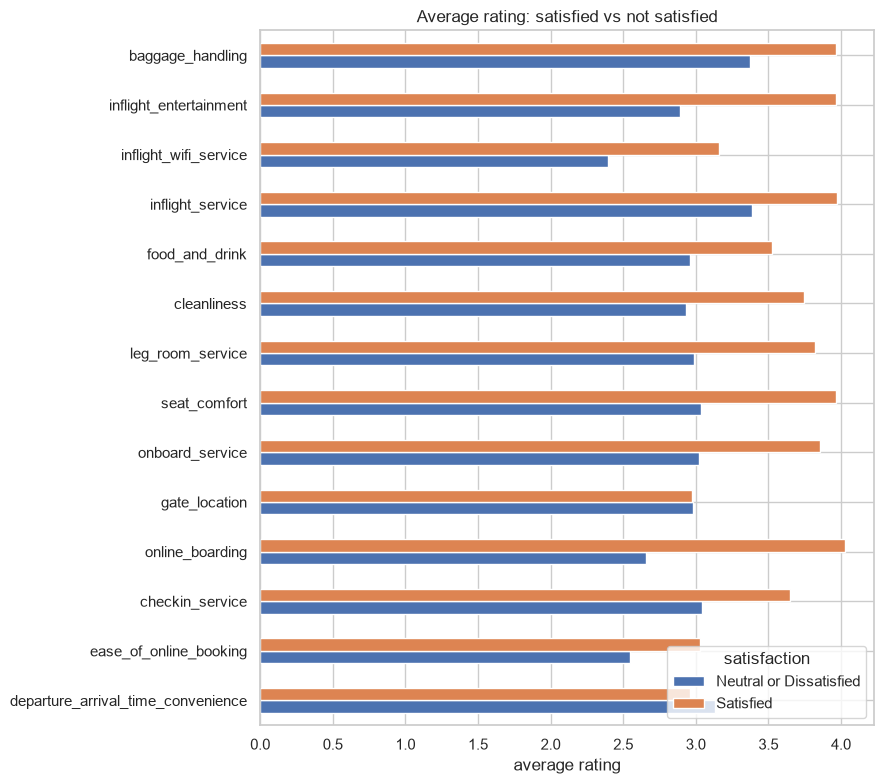

online_boarding                       1.37
inflight_entertainment                1.07
seat_comfort                          0.93
onboard_service                       0.84
leg_room_service                      0.83
cleanliness                           0.81
inflight_wifi_service                 0.76
checkin_service                       0.61
baggage_handling                      0.59
inflight_service                      0.58
food_and_drink                        0.57
ease_of_online_booking                0.48
gate_location                        -0.01
departure_arrival_time_convenience   -0.17
Name: gap, dtype: float64

In [61]:
# average score of each rating, for satisfied and not satisfied passengers
means = eda.groupby("satisfaction")[rating_cols].mean().T

means.plot(kind="barh", figsize=(9, 8))
plt.title("Average rating: satisfied vs not satisfied")
plt.xlabel("average rating")
plt.tight_layout()
plt.savefig(fig_folder + "14_average_ratings.png", dpi=120, bbox_inches="tight")
plt.show()

means["gap"] = means["Satisfied"] - means["Neutral or Dissatisfied"]
means["gap"].sort_values(ascending=False).round(2)

observation :
- here satisfied passengers rate nearly everything higher, and online boarding has the biggest gap (1.37 points).
- Gate location has no gap at all (-0.01). 
- Time convenience is the one rating where satisfied passengers score slightly lower (-0.17).

## Multivariate Analysis

#### travel type Vs class together

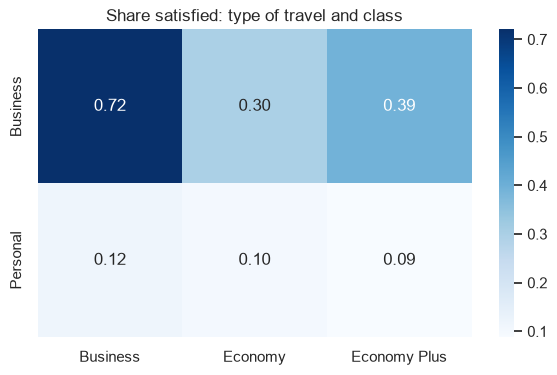

In [62]:
table = eda.pivot_table(values="satisfied", index="type_of_travel", columns="travel_class", aggfunc="mean")

plt.figure(figsize=(7, 4))
sns.heatmap(table, annot=True, fmt=".2f", cmap="Blues")
plt.title("Share satisfied: type of travel and class")
plt.xlabel("")
plt.ylabel("")
plt.savefig(fig_folder + "15_travel_and_class.png", dpi=120, bbox_inches="tight")
plt.show()

observation :

- Basically the darkest square is business travellers in Business class (0.72). Everyone on a personal trip is under 0.12, whatever class they sit in. The two columns work together.



#### Correlation Heatmap

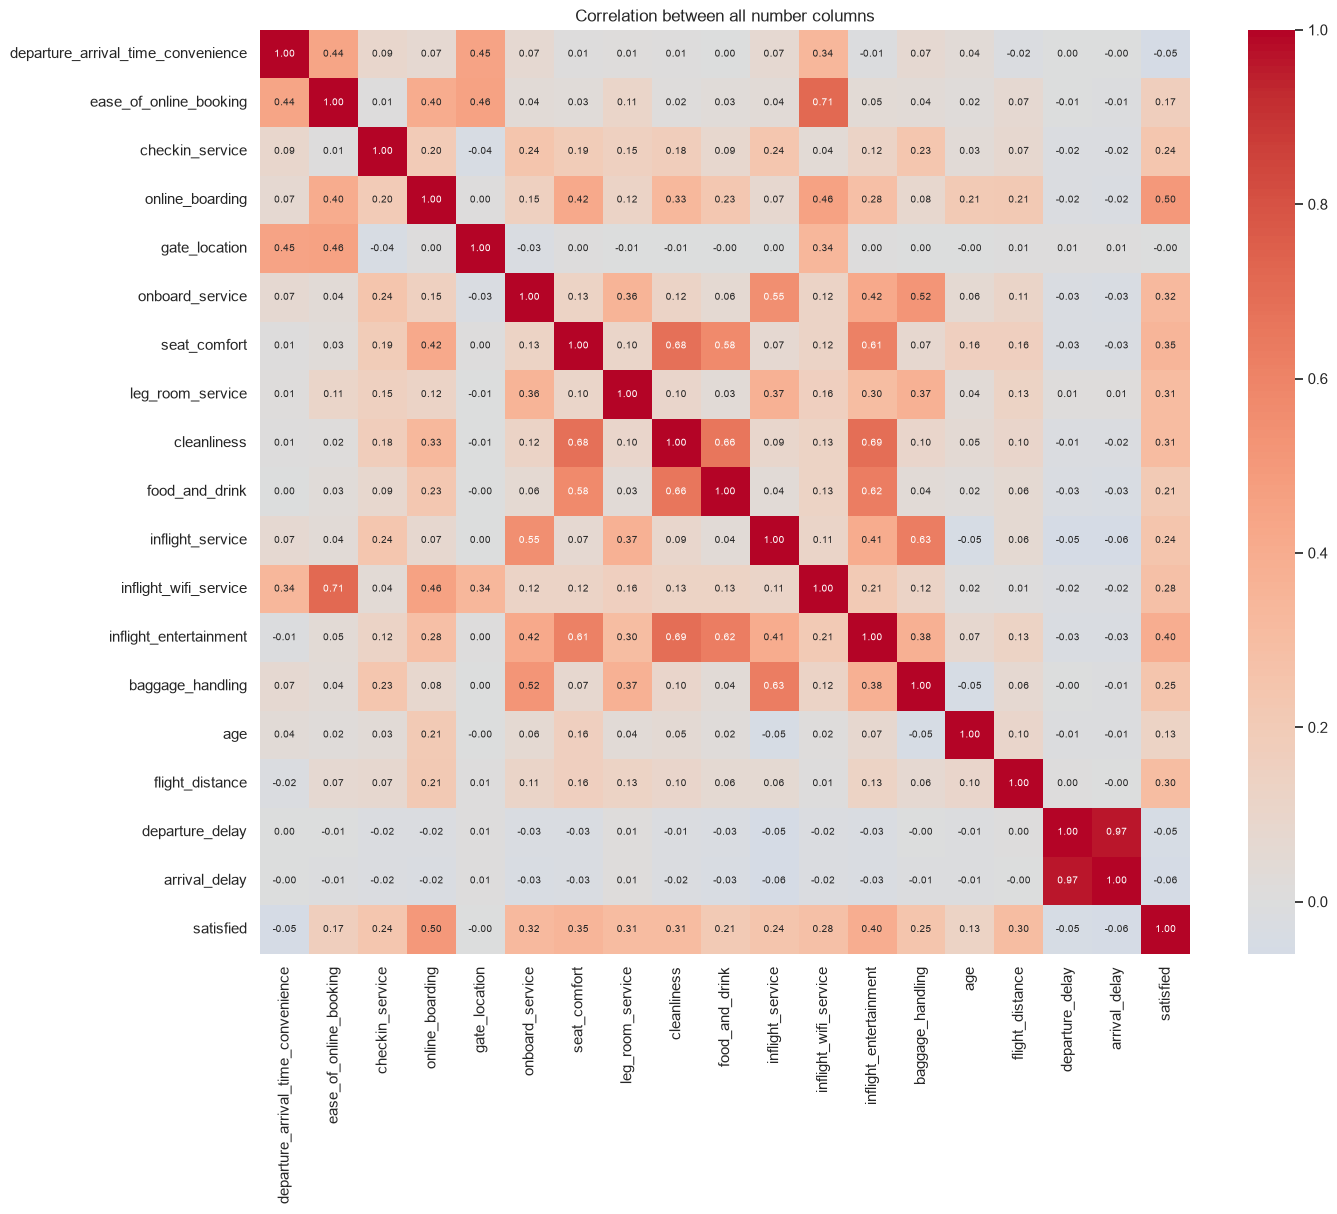

In [63]:
corr = eda[rating_cols + num_cols + ["satisfied"]].corr()

plt.figure(figsize=(15, 12))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, annot_kws={"size": 7})
plt.title("Correlation between all number columns")
plt.savefig(fig_folder + "16_correlation_heatmap.png", dpi=120, bbox_inches="tight")
plt.show()

observation :
- here several ratings move together, especially the cabin comfort group (seat, cleanliness, food, entertainment). Linear models can get confused when inputs are this closely related, and tree models are less affected. The two delay columns are the clearest duplicate.

#### Correlation with satisfaction,ranked

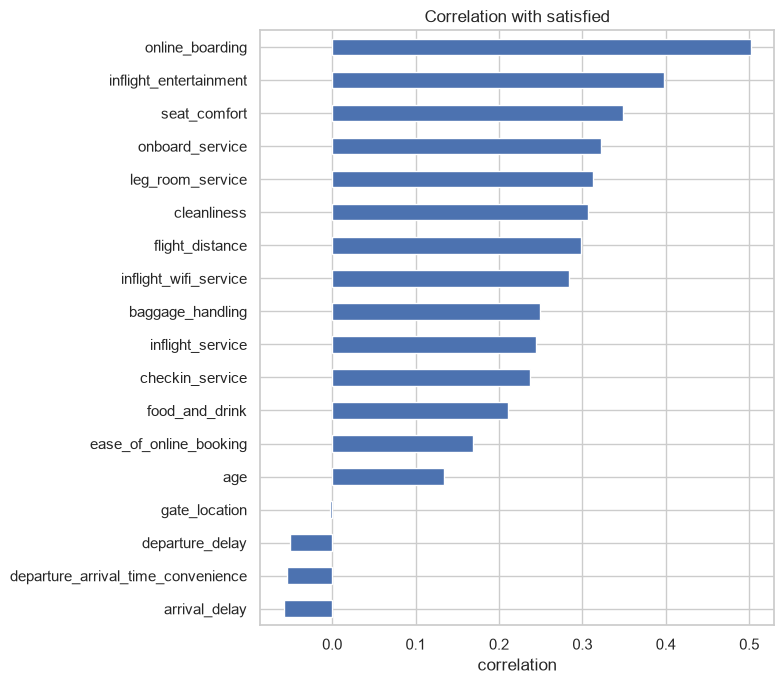

In [64]:
# correlation of each column with satisfied, sorted
with_target = corr["satisfied"].drop("satisfied").sort_values()

plt.figure(figsize=(8, 7))
with_target.plot(kind="barh")
plt.title("Correlation with satisfied")
plt.xlabel("correlation")
plt.tight_layout()
plt.savefig(fig_folder + "17_correlation_with_target.png", dpi=120, bbox_inches="tight")
plt.show()

observation :
- here online boarding is longest (0.50), then entertainment with 0.40, seat comfort with 0.35, and so on, down to three tiny negative bars for the delays and time convenience, and gate location at zero.

#### departure delay vs arrival delay

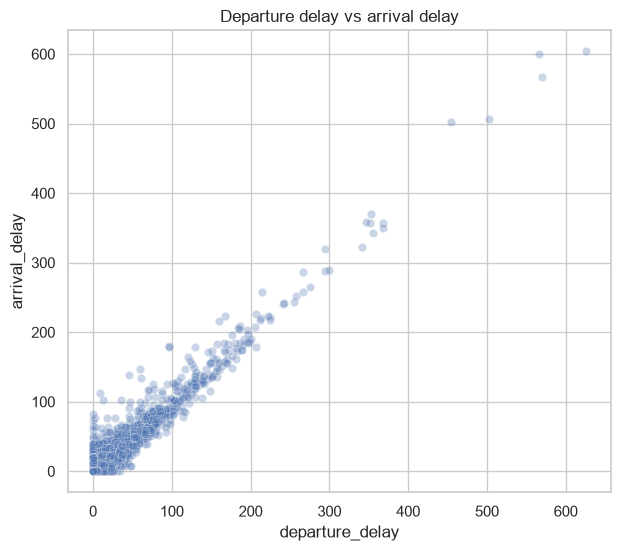

In [65]:
# 5000 random passengers is enough to see the shape
small = eda.sample(5000, random_state=42)

plt.figure(figsize=(7, 6))
sns.scatterplot(data=small, x="departure_delay", y="arrival_delay", alpha=0.3)
plt.title("Departure delay vs arrival delay")
plt.savefig(fig_folder + "18_delay_scatter.png", dpi=120, bbox_inches="tight")
plt.show()

observation : 
- the two columns are nearly the same thing, which matches the 0.965 correlation. We only need one, or a combined column.

#### distance by class

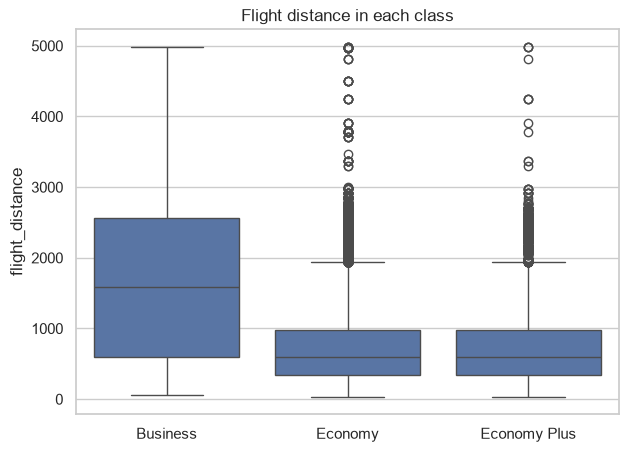

In [66]:
plt.figure(figsize=(7, 5))
sns.boxplot(data=df, x="travel_class", y="flight_distance")
plt.title("Flight distance in each class")
plt.xlabel("")
plt.savefig(fig_folder + "19_distance_by_class.png", dpi=120, bbox_inches="tight")
plt.show()

observation :
- here the  distance and class overlap, Passengers on long flights are mostly in Business class.

#### Pairplot

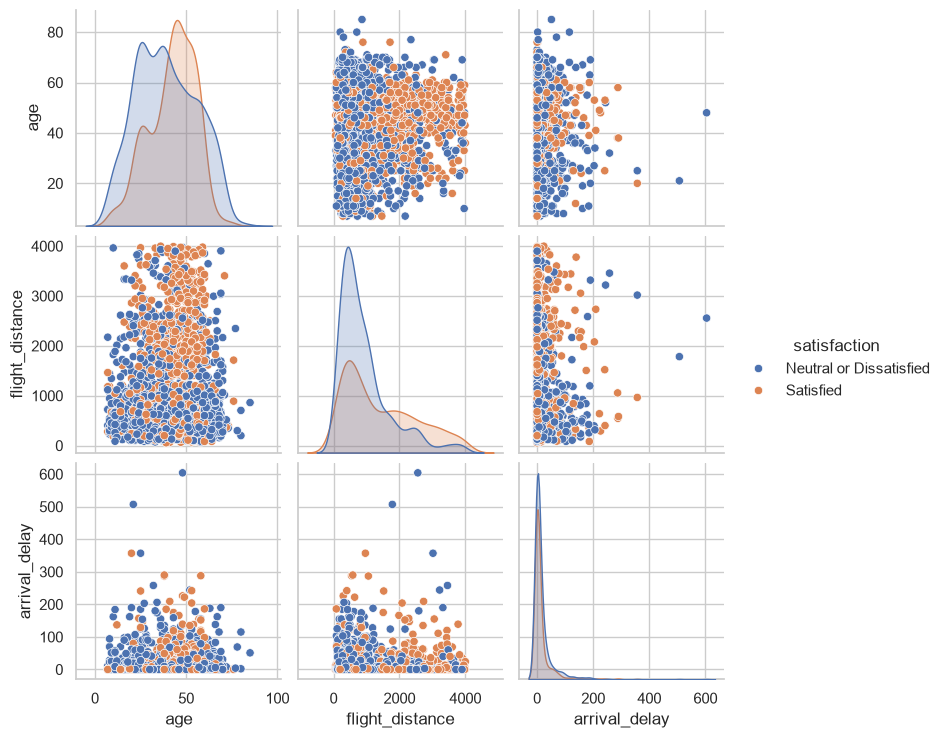

In [67]:
small = eda.sample(2000, random_state=42)

g = sns.pairplot(data=small, vars=["age", "flight_distance", "arrival_delay"], hue="satisfaction")
g.savefig(fig_folder + "20_pairplot.png", dpi=100)
plt.show()

observation :

- well this is a 3 by 3 grid. The diagonal shows the shape of each column, split by answer. The other squares are scatter plots of each pair.

- age (top-left shape): the not-satisfied curve peaks at about 25 and the satisfied curve at about 45. This is the age hump again.

- flight_distance: not-satisfied passengers are mostly on short flights. Satisfied passengers are spread over longer ones.

- arrival_delay: both groups pile up at 0.

- The scatter squares show no tidy pattern between age, distance and delay themselves. They're mostly clouds.

In [68]:
import os
files = sorted(os.listdir(fig_folder))
print(len(files), "charts saved:")
for name in files:
    print(name)

20 charts saved:
01_target.png
02_categorical_columns.png
03_histograms.png
04_delays_zoomed.png
05_boxplots.png
06_ratings_counts.png
07_category_vs_satisfied.png
08_ratings_vs_satisfied.png
09_age.png
10_distance.png
11_delay.png
12_wifi_vs_boarding.png
13_zero_ratings.png
14_average_ratings.png
15_travel_and_class.png
16_correlation_heatmap.png
17_correlation_with_target.png
18_delay_scatter.png
19_distance_by_class.png
20_pairplot.png
